# Task 7 — Sales Forecasting

**Objectif :** prédire les ventes hebdomadaires futures à partir de l'historique.

**Dataset :** Walmart Sales (Kaggle) — 6435 lignes, 45 magasins, données hebdomadaires 2010-2012.

In [1]:
# setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Chargement des données

In [2]:
df = pd.read_csv("../data/Walmart.csv")
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

print(df.shape)
df.head()

(6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
print(df.isnull().sum().sum())
print("Période :", df['Date'].min().date(), "→", df['Date'].max().date())
print("Magasins :", df['Store'].nunique())

0
Période : 2010-02-05 → 2012-10-26
Magasins : 45


## 2. Vue d'ensemble des ventes

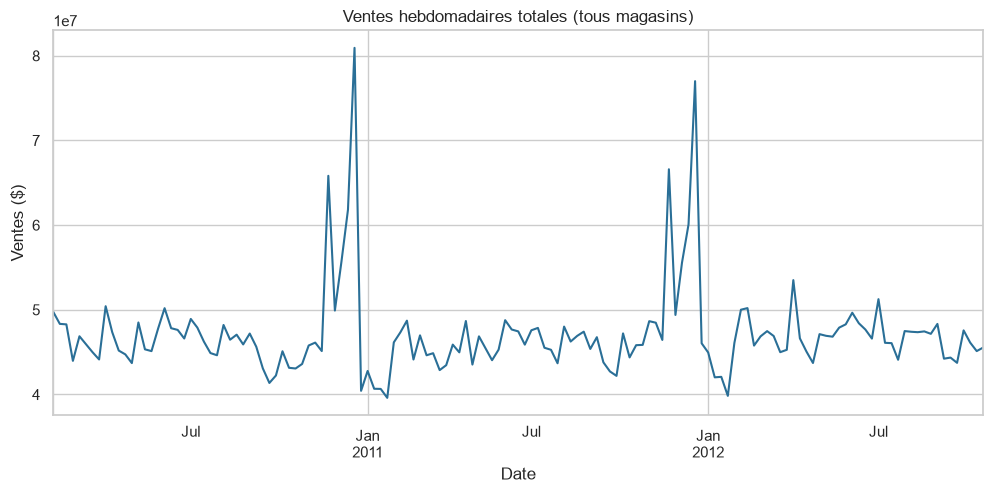

In [4]:
# total des ventes toutes stores confondues, semaine par semaine
weekly_total = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(12, 5))
weekly_total.plot(color="#2a6f97")
plt.title("Ventes hebdomadaires totales (tous magasins)")
plt.ylabel("Ventes ($)")
plt.savefig("../outputs/01_total_weekly_sales.png", dpi=150, bbox_inches="tight")
plt.show()

→ Des pics très nets se détachent (fin d'année, périodes de fêtes)

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_26120\2526720920.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Holiday_Flag", y="Weekly_Sales", data=df, palette="Set2", ax=ax)
C:\Users\Administrateur\AppData\Local\Temp\ipykernel_26120\2526720920.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Semaine normale", "Semaine de fête"])


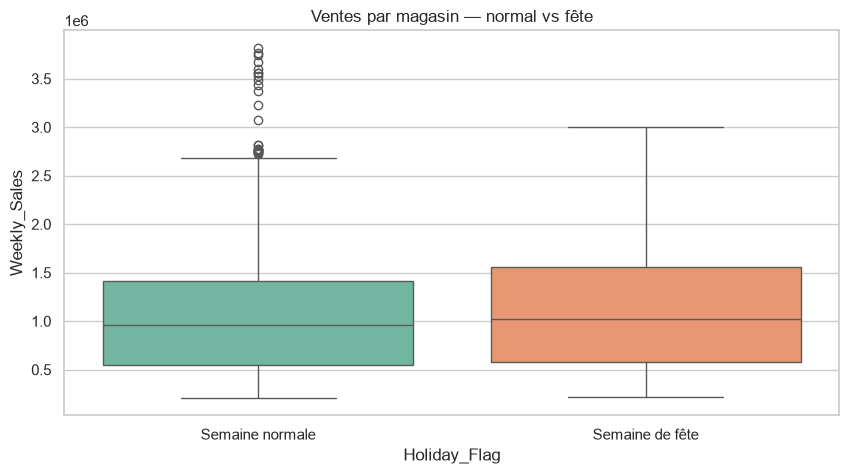

In [5]:
# comparaison ventes normales vs semaines de fêtes
fig, ax = plt.subplots()
sns.boxplot(x="Holiday_Flag", y="Weekly_Sales", data=df, palette="Set2", ax=ax)
ax.set_xticklabels(["Semaine normale", "Semaine de fête"])
ax.set_title("Ventes par magasin — normal vs fête")
plt.savefig("../outputs/02_holiday_vs_normal.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Feature engineering temporel

In [6]:
# décomposition de la date + valeurs décalées (lag) pour capturer la tendance récente
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

# lag et moyenne glissante calculés PAR magasin (chaque store a sa propre dynamique)
df["Sales_Lag1"] = df.groupby("Store")["Weekly_Sales"].shift(1)
df["Sales_Lag2"] = df.groupby("Store")["Weekly_Sales"].shift(2)
df["Sales_RollingMean4"] = df.groupby("Store")["Weekly_Sales"].shift(1).rolling(4).mean().reset_index(drop=True)

df = df.dropna().reset_index(drop=True)
print(df.shape)
df[["Store", "Date", "Weekly_Sales", "Sales_Lag1", "Sales_Lag2", "Sales_RollingMean4"]].head()

(6255, 14)


,Store,Date,Weekly_Sales,Sales_Lag1,Sales_Lag2,Sales_RollingMean4
0,1,2010-03-05,1554806.68,1409727.59,1611968.17,1.576836e+06
1,1,2010-03-12,1439541.59,1554806.68,1409727.59,1.554615e+06
2,1,2010-03-19,1472515.79,1439541.59,1554806.68,1.504011e+06
3,1,2010-03-26,1404429.92,1472515.79,1439541.59,1.469148e+06
4,1,2010-04-02,1594968.28,1404429.92,1472515.79,1.467823e+06


## 4. Split train/test — respect de l'ordre temporel

⚠️ Pas de `train_test_split` aléatoire ici : en prévision temporelle, tester sur le passé alors qu'on a appris sur le futur fausserait totalement l'évaluation. On coupe par date : les dernières semaines vont dans le test.

In [7]:
cutoff_date = df["Date"].quantile(0.8, interpolation="nearest")

train = df[df["Date"] < cutoff_date]
test = df[df["Date"] >= cutoff_date]

features = ["Store", "Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment",
            "Year", "Month", "WeekOfYear", "Sales_Lag1", "Sales_Lag2", "Sales_RollingMean4"]

X_train, y_train = train[features], train["Weekly_Sales"]
X_test, y_test = test[features], test["Weekly_Sales"]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Coupure :", cutoff_date.date())

Train: (4995, 12)  Test: (1260, 12)
Coupure : 2012-04-20


## 5. Modèles de régression

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    results.append({
        "Modèle": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,Modèle,MAE,RMSE,R2
3,LightGBM,41194.896815,59502.915984,0.987552
2,XGBoost,46355.188696,65512.531411,0.984910
0,Linear Regression,53072.923593,71212.857046,0.982170
1,Random Forest,50709.380826,71534.856092,0.982009


## 6. Visualisation — réel vs prédit (meilleur modèle)

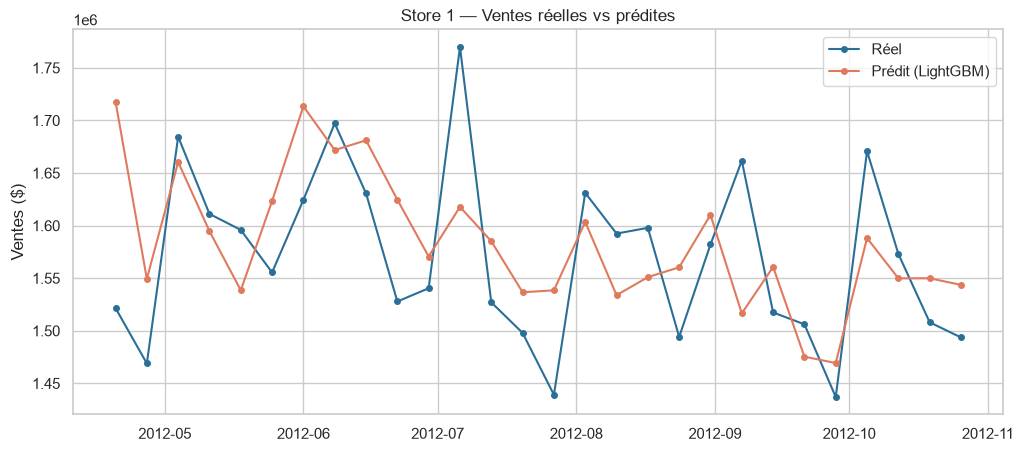

In [9]:
best_model_name = results_df.iloc[0]["Modèle"]
best_pred = predictions[best_model_name]

# on prend un seul magasin pour que le graphe reste lisible
sample_store = test["Store"].iloc[0]
mask = test["Store"] == sample_store

plt.figure(figsize=(12, 5))
plt.plot(test.loc[mask, "Date"], test.loc[mask, "Weekly_Sales"], label="Réel", color="#2a6f97", marker="o", markersize=4)
plt.plot(test.loc[mask, "Date"], best_pred[mask.values], label=f"Prédit ({best_model_name})", color="#e07a5f", marker="o", markersize=4)
plt.title(f"Store {sample_store} — Ventes réelles vs prédites")
plt.ylabel("Ventes ($)")
plt.legend()
plt.savefig("../outputs/03_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Moyennes glissantes et décomposition saisonnière

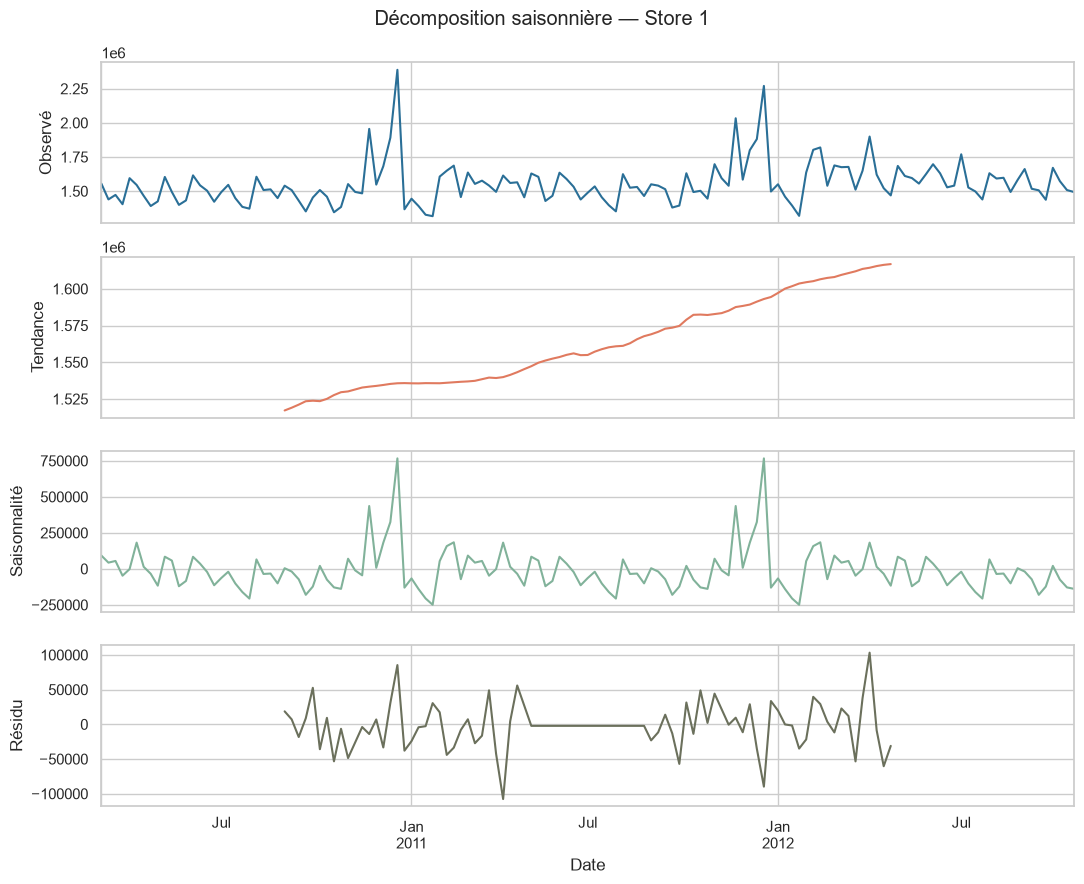

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# décomposition sur un seul magasin, séries hebdomadaires -> period=52 (1 an)
store_series = df[df["Store"] == sample_store].set_index("Date")["Weekly_Sales"]

decomposition = seasonal_decompose(store_series, model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
decomposition.observed.plot(ax=axes[0], color="#2a6f97"); axes[0].set_ylabel("Observé")
decomposition.trend.plot(ax=axes[1], color="#e07a5f"); axes[1].set_ylabel("Tendance")
decomposition.seasonal.plot(ax=axes[2], color="#81b29a"); axes[2].set_ylabel("Saisonnalité")
decomposition.resid.plot(ax=axes[3], color="#6b705c"); axes[3].set_ylabel("Résidu")
plt.suptitle(f"Décomposition saisonnière — Store {sample_store}")
plt.tight_layout()
plt.savefig("../outputs/04_seasonal_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Feature importance (meilleur modèle à base d'arbres)

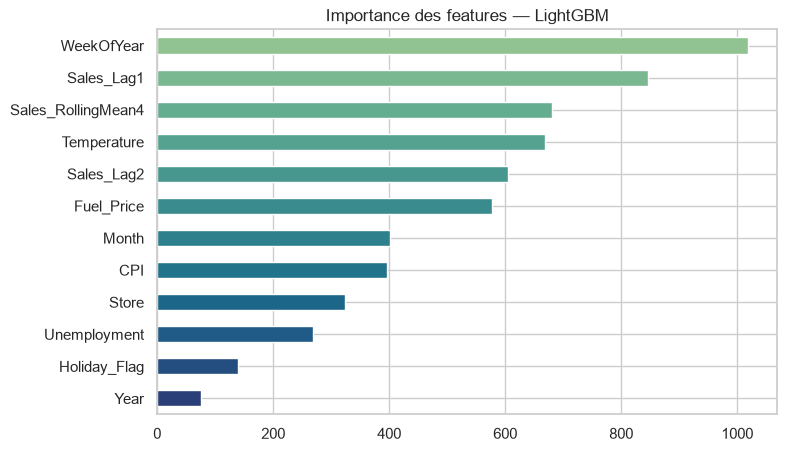

In [11]:
tree_models = {k: v for k, v in models.items() if hasattr(v, "feature_importances_")}
best_tree_name = max(tree_models, key=lambda n: results_df.set_index("Modèle").loc[n, "R2"]) if tree_models else None

if best_tree_name:
    importances = pd.Series(models[best_tree_name].feature_importances_, index=features).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh", color=sns.color_palette("crest", len(importances)))
    plt.gca().invert_yaxis()
    plt.title(f"Importance des features — {best_tree_name}")
    plt.savefig("../outputs/05_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

**Prochaine étape possible :** ajouter une validation temporelle plus fine (walk-forward validation, plusieurs coupures) plutôt qu'une seule séparation train/test, pour confirmer que la performance tient sur plusieurs périodes différentes.